# **Part II: Classical Classification Task**

# CIFAR-10: Classical Multi-Class Classification

In this part of the project, we evaluate three classical machine learning models on the CIFAR-10 dataset: Multiclass Logistic Regression, Linear SVM, and KNN.

To ensure a fair comparison, all models are trained on the same training and validation split.  
Hyperparameters are selected using validation accuracy only, and the test set is used only once at the very end, after the final model has already been chosen.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from tensorflow.keras.datasets import cifar10

In [2]:
# Load CIFAR-10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

X_train_full = X_train_full.reshape(len(X_train_full), -1)
X_test = X_test.reshape(len(X_test), -1)

print("Full training set:", X_train_full.shape)
print("Test set:", X_test.shape)


Full training set: (50000, 3072)
Test set: (10000, 3072)


In [3]:
# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (40000, 3072)
Validation: (10000, 3072)


## Preprocessing and Experimental Setup

CIFAR-10 images are provided as 32x32x3 color images.  
Since the classical models used in this section operate on vector inputs rather than image tensors, each image is flattened into a one-dimensional feature vector.

We then standardize the features and apply PCA before classification.  
Standardization is important because the feature scales may affect both linear models and distance-based methods.  
PCA is used to reduce the dimensionality of the input space, making the classification task more tractable for classical models and reducing computational cost.

All preprocessing steps are applied inside a pipeline, so they are fitted on the training data only and then applied consistently to validation and test data.

## Logistic Regression tuning

In [4]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
val_scores_lr = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", LogisticRegression(max_iter=1000, C=C, solver="lbfgs"))
    ])

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    val_scores_lr.append(val_acc)

    print(f"C={C}, Validation Accuracy={val_acc:.4f}")


C=0.001, Validation Accuracy=0.3966
C=0.01, Validation Accuracy=0.3983
C=0.1, Validation Accuracy=0.3987
C=1, Validation Accuracy=0.3987
C=10, Validation Accuracy=0.3987
C=100, Validation Accuracy=0.3987


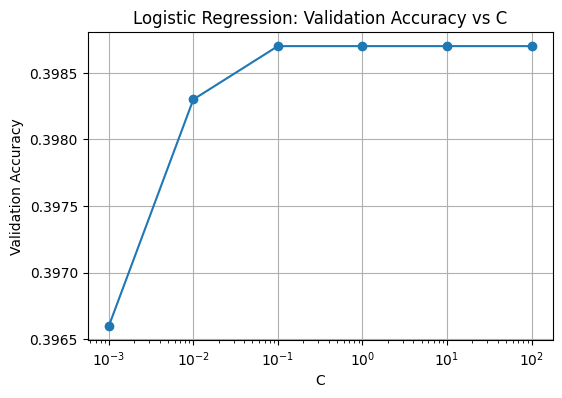

In [5]:
plt.figure(figsize=(6,4))
plt.plot(C_values, val_scores_lr, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Logistic Regression: Validation Accuracy vs C")
plt.grid(True)
plt.show()

The validation curve shows that the best Logistic Regression validation accuracy in our search is approximately 0.3987, achieved by several values of \( C \), namely \( 0.1, 1, 10, \) and \( 100 \).

Since the smallest value among the best-performing configurations is \( C = 0.1 \), we select it as the final Logistic Regression hyperparameter. This choice is consistent with validation performance and also prefers the simpler regularized configuration among equally performing alternatives.

## Linear SVM tuning

In [6]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
val_scores_svm = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", LinearSVC(C=C, max_iter=5000, random_state=SEED))
    ])

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    val_scores_svm.append(val_acc)

    print(f"C={C}, Validation Accuracy={val_acc:.4f}")


C=0.001, Validation Accuracy=0.3920
C=0.01, Validation Accuracy=0.3922
C=0.1, Validation Accuracy=0.3920
C=1, Validation Accuracy=0.3920
C=10, Validation Accuracy=0.3919
C=100, Validation Accuracy=0.3919


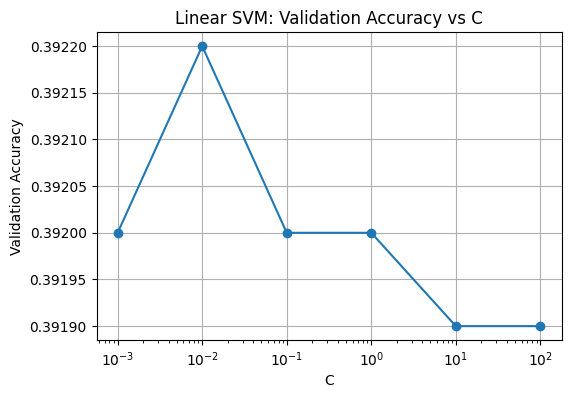

In [7]:
plt.figure(figsize=(6,4))
plt.plot(C_values, val_scores_svm, marker='o')
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Linear SVM: Validation Accuracy vs C")
plt.grid(True)
plt.show()

The validation curve shows that the best Linear SVM configuration in our search is obtained at \( C = 0.01 \), with a validation accuracy of approximately 0.3922.

Although the differences across the tested values are relatively small, we select this configuration strictly because it achieved the highest validation accuracy on the validation set. This keeps the model selection process separate from the held-out test set.

## KNN tuning

In [8]:
k_values = [1, 3, 5, 7, 9, 11, 15]
val_scores_knn = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    val_scores_knn.append(val_acc)

    print(f"k={k}, Validation Accuracy={val_acc:.4f}")

k=1, Validation Accuracy=0.3817
k=3, Validation Accuracy=0.3582
k=5, Validation Accuracy=0.3695
k=7, Validation Accuracy=0.3718
k=9, Validation Accuracy=0.3719
k=11, Validation Accuracy=0.3705
k=15, Validation Accuracy=0.3684


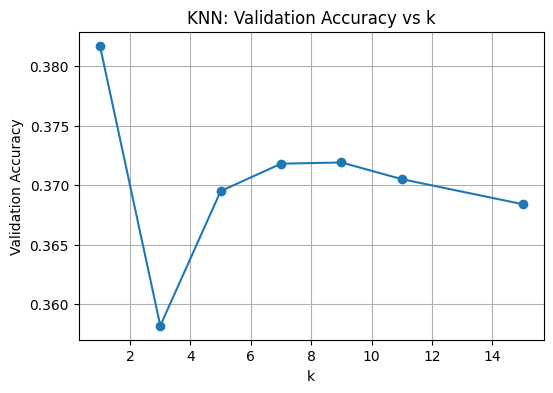

In [9]:
plt.figure(figsize=(6,4))
plt.plot(k_values, val_scores_knn, marker='o')
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("KNN: Validation Accuracy vs k")
plt.grid(True)
plt.show()

The validation curve shows that the best KNN configuration in our search is obtained at \( k = 1 \), with a validation accuracy of approximately 0.3817.

This result is consistent with the fact that smaller values of \( k \) produce more flexible decision boundaries. Although such choices may increase variance, we select \( k = 1 \) here strictly because it achieved the highest validation accuracy on the validation set.

In [10]:
best_C_lr = C_values[np.argmax(val_scores_lr)]
best_C_svm = C_values[np.argmax(val_scores_svm)]
best_k_knn = k_values[np.argmax(val_scores_knn)]

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "KNN"],
    "Best Hyperparameter": [
        f"C={best_C_lr}",
        f"C={best_C_svm}",
        f"k={best_k_knn}"
    ],
    "Best Validation Accuracy": [
        max(val_scores_lr),
        max(val_scores_svm),
        max(val_scores_knn)
    ]
})

results_df = results_df.sort_values("Best Validation Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Best Hyperparameter,Best Validation Accuracy
0,Logistic Regression,C=0.1,0.3987
1,Linear SVM,C=0.01,0.3922
2,KNN,k=1,0.3817


## Model Comparison

The table above summarizes the best validation result obtained for each classical model family, using the same training and validation split and the same preprocessing pipeline structure.

Among the tested models, Logistic Regression achieved the highest validation accuracy, with \( C = 0.1 \) and a validation accuracy of 0.3987.  
Therefore, it is selected as the final classical model for test evaluation.

This comparison also highlights the limitations of classical methods on high-dimensional image data.  
Unlike convolutional neural networks, these models do not directly exploit the spatial structure of images, so even after dimensionality reduction with PCA, their performance remains limited.

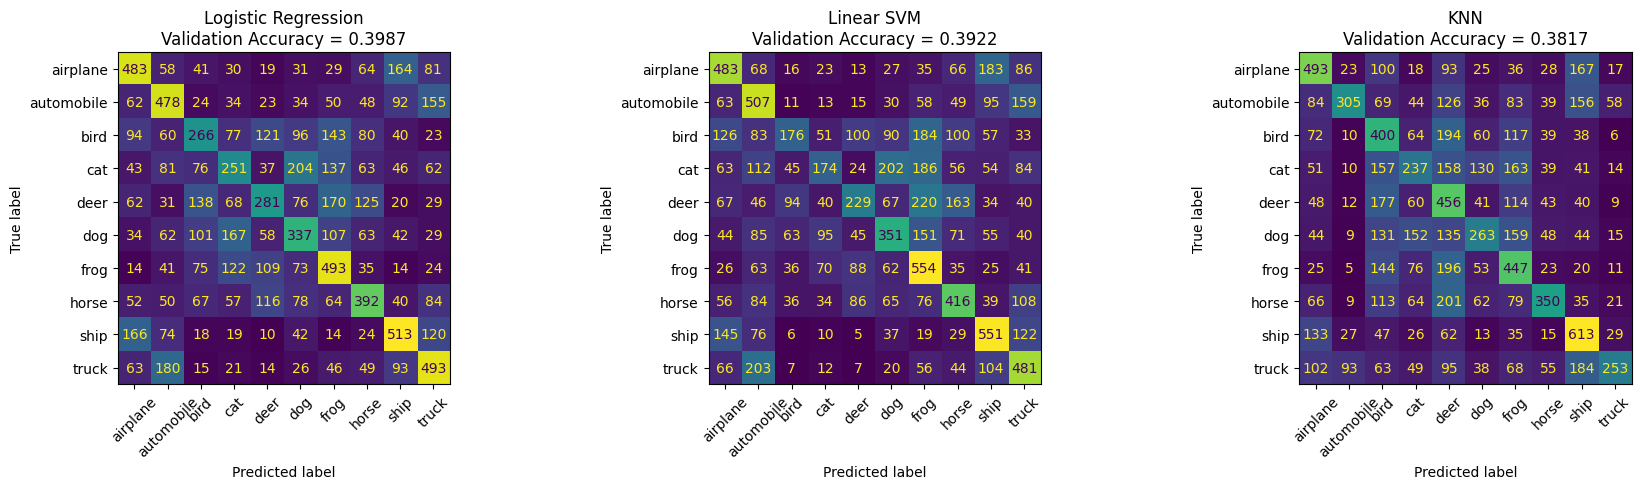

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

best_C_lr = C_values[np.argmax(val_scores_lr)]
best_C_svm = C_values[np.argmax(val_scores_svm)]
best_k_knn = k_values[np.argmax(val_scores_knn)]

best_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, svd_solver="full")),
    ("clf", LogisticRegression(max_iter=1000, C=best_C_lr, solver="lbfgs"))
])

best_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, svd_solver="full")),
    ("clf", LinearSVC(C=best_C_svm, max_iter=5000, random_state=SEED))
])

best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, svd_solver="full")),
    ("clf", KNeighborsClassifier(n_neighbors=best_k_knn))
])

models = {
    "Logistic Regression": best_lr,
    "Linear SVM": best_svm,
    "KNN": best_knn
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    cm = confusion_matrix(y_val, val_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{name}\nValidation Accuracy = {val_acc:.4f}")

plt.tight_layout()
plt.show()

The validation confusion matrices provide a more detailed comparison than validation accuracy alone.

They show that some classes, such as ship and frog, are recognized more reliably, while visually similar animal classes such as bird, cat, deer, and dog remain more difficult and are often confused.

This behavior is consistent with the limitations of classical models on flattened image representations, where the spatial structure of the image is not explicitly preserved.

## Final Model Selection Before Test Evaluation

At this stage, we completed the validation-based comparison across the three classical model families.

Among the tested models, Logistic Regression achieved the highest validation accuracy, with \( C = 0.1 \) and a validation accuracy of 0.3987. Therefore, it is selected as the final classical model.

The final model is selected strictly according to validation accuracy only.  
Since the test set must remain untouched during hyperparameter tuning and model comparison, it is used only now, after the final model has already been chosen.

After selecting the best-performing configuration, we retrain it on the combined training and validation data and then evaluate it once on the held-out test set.

In [12]:
best_row = results_df.iloc[0]

print("Selected final model based on validation performance:")
print(best_row)

if best_row["Model"] == "Logistic Regression":
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", LogisticRegression(max_iter=1000, C=best_C_lr, solver="lbfgs"))
    ])
elif best_row["Model"] == "Linear SVM":
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", LinearSVC(C=best_C_svm, max_iter=5000, random_state=SEED))
    ])
else:
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, svd_solver="full")),
        ("clf", KNeighborsClassifier(n_neighbors=best_k_knn))
    ])

X_combined = np.vstack([X_train, X_val])
y_combined = np.concatenate([y_train, y_val])

final_model.fit(X_combined, y_combined)

test_preds = final_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"Final Test Accuracy: {test_acc:.4f}")


Selected final model based on validation performance:
Model                       Logistic Regression
Best Hyperparameter                       C=0.1
Best Validation Accuracy                 0.3987
Name: 0, dtype: object
Final Test Accuracy: 0.4024


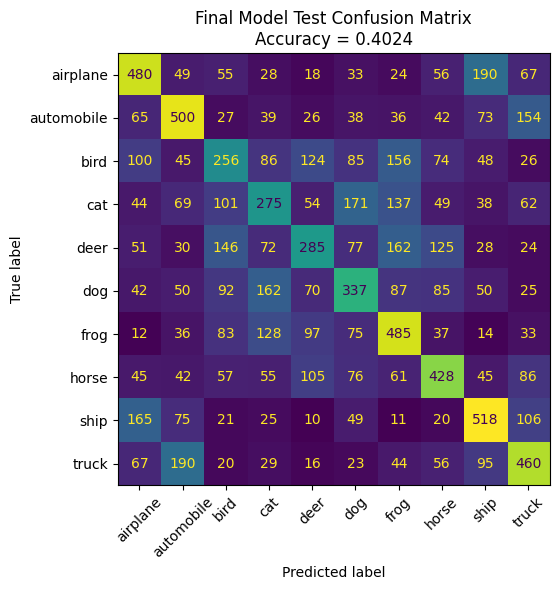

In [13]:
cm_test = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp.plot(ax=plt.gca(), xticks_rotation=45, colorbar=False)
plt.title(f"Final Model Test Confusion Matrix\nAccuracy = {test_acc:.4f}")
plt.tight_layout()
plt.show()

The final test confusion matrix is consistent with the validation analysis.

The selected Logistic Regression model achieves a test accuracy of 0.4024, which is close to its validation performance and therefore supports the stability of the model selection process.

The matrix also shows that some semantically or visually similar classes, such as automobile and truck or cat and dog, remain difficult to separate using classical models on flattened image features.

## Final Discussion

Among the classical models tested here, the final selection is based on validation performance only.

The selected **Logistic Regression model** achieved a validation accuracy of 0.3987 and a final test accuracy of 0.4024. These results show that classical machine learning methods can achieve reasonable performance on CIFAR-10 after preprocessing and dimensionality reduction, but their accuracy remains limited.

A central reason is that flattening the images removes the local spatial structure that is naturally exploited by convolutional neural networks. Therefore, even though PCA helps reduce dimensionality and improve tractability, classical models still struggle to fully capture the complexity of image data.